<a href="https://colab.research.google.com/github/jpnoug/SexDec/blob/master/melchiors_catalog_download_spectrum.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MELCHIORS Catalog → Alpy 600 FITS 1D

Cherche une etoile dans le catalogue MELCHIORS, telecharge le spectre HERMES, et exporte en FITS 1D pour Alpy 600.

In [1]:
!pip install astropy openpyxl odfpy specutils -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 717.0/717.0 kB 2.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 971.7/971.7 kB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.9/110.9 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 364.6/364.6 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 173.7/173.7 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/49.3 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.8/105.8 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 350.3/350.3 kB 30.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.3/59.3 kB 2.4 MB/s eta 0:00:00


In [2]:
from google.colab import files
import os

print('Selectionner le fichier catalogue_Melchiors_AB.ods...')
uploaded = files.upload()
CATALOG_FILE = list(uploaded.keys())[0]
print(f'Fichier catalogue charge : {CATALOG_FILE}')

Selectionner le fichier catalogue_Melchiors_AB.ods...


Saving catalogue_Melchiors_AB.ods to catalogue_Melchiors_AB.ods
Fichier catalogue charge : catalogue_Melchiors_AB.ods


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.table import Table
from astropy import units as u
from scipy.interpolate import interp1d
from specutils import Spectrum
from specutils.manipulation import gaussian_smooth, FluxConservingResampler
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.dpi'] = 100
print('Imports OK')


Imports OK


In [4]:
# Charger le catalogue
catalog = pd.read_excel(CATALOG_FILE, sheet_name='catalogue_Melchiors', engine='odf')
print(f"Catalogue charge : {len(catalog)} entrees")


Catalogue charge : 3256 entrees


In [5]:
# ---------------------------------------------------------------
# MODIFIER ICI : entrer le numéro HD de l'étoile
HD_NUMBER = 108382
# ---------------------------------------------------------------

matches = catalog[
    (catalog['TARGET catalog'].str.strip().str.upper() == 'HD') &
    (catalog['TARGET number'].astype(str).str.strip() == str(HD_NUMBER))
]

if len(matches) == 0:
    print(f'HD {HD_NUMBER} non trouvee dans le catalogue MELCHIORS.')
else:
    print(f"Trouve {len(matches)} spectre(s) pour HD {HD_NUMBER} :")
    for _, row in matches.iterrows():
        print(f"  obsid={row['obsid']}  Star name={row['Star name']}  type={row['Spectral type']}")


Trouve 1 spectre(s) pour HD 108382 :
  obsid=340868  Star name=*16 Com  type=A4V


In [7]:
# Prendre le premier match (ou modifier si plusieurs spectres pour une etoile)
selected = matches.iloc[0]
fits_url = selected['Spectrum fits link']
obsid = selected['obsid']
star_name = selected['Star name']
sptype = selected['Spectral type']

print(f"Selection : {star_name} ({sptype})")
print(f"  obsid : {obsid}")
print(f"  URL : {fits_url[:80]}...")

# Telecharger le FITS
import requests
print(f"\nTelechargement en cours...")
FITS_FILE = f'{obsid}_spectrum.fits'
try:
    r = requests.get(fits_url, timeout=30, headers={'Referer': 'https://royer.se/melchiors.html'})
    if r.status_code == 200:
        with open(FITS_FILE, 'wb') as f:
            f.write(r.content)
        print(f"Fichier telecharge : {FITS_FILE}")
        print(f"Taille : {os.path.getsize(FITS_FILE)/1024/1024:.1f} MB")
    else:
        print(f"Erreur HTTP {r.status_code}")
except Exception as e:
    print(f"Erreur telechargement : {e}")

Selection : *16 Com (A4V)
  obsid : 340868
  URL : https://set-p-stweb.bm.icts.kuleuven.be/spectra/340868_melchiors_spectrum.fits...

Telechargement en cours...
Fichier telecharge : 340868_spectrum.fits
Taille : 6.4 MB


In [8]:
# Ouvrir le FITS telecharge
with fits.open(FITS_FILE) as hdul:
    header0 = hdul[0].header
    table = Table(hdul[1].data)

meta = {
    'object'    : header0.get('OBJECT', 'N/A'),
    'unseq'     : header0.get('UNSEQ', 'N/A'),
    'date_obs'  : header0.get('DATE-OBS', 'N/A'),
    'exptime'   : header0.get('EXPTIME', float('nan')),
    'instrume'  : header0.get('INSTRUME', 'N/A'),
    'telescop'  : header0.get('TELESCOP', 'N/A'),
    'bjd'       : header0.get('BJD', float('nan')),
    'bvcor_kms' : header0.get('BVCOR', float('nan')),
    'ra'        : float(header0.get('RA', 0)),
    'dec'       : float(header0.get('DEC', 0)),
}

print(f"Object    : {meta['object']}")
print(f"UNSEQ     : {meta['unseq']}")
print(f"Date      : {meta['date_obs']}")
print(f"Instrument: {meta['instrume']} / {meta['telescop']}")
print(f"Points    : {len(table)}")

Object    : HD 108382
UNSEQ     : 340868
Date      : 2011-03-28T01:29:08.583112
Instrument: HERMES / Mercator
Points    : 167719


In [9]:
# Extraction flux_tac
wave = np.array(table['wave'], dtype=np.float64)
flux_tac = np.array(table['flux_tac'], dtype=np.float64)

mask = np.isfinite(flux_tac) & np.isfinite(wave) & (flux_tac > 0)
w_ok = wave[mask]
ft_ok = flux_tac[mask]

print(f"Points valides : {mask.sum()}")

Points valides : 167489


In [16]:
# ---------------------------------------------------------------
# Parametres de sortie
DELTA_OUT = 0.5     # pas de sortie en A/pixel (ex: 2.5 pour Alpy 600)
R_TARGET  = 600     # resolution spectrale cible (ex: 600 pour Alpy 600)
LMIN_OUT  = 3800.0  # limite bleue (A)
LMAX_OUT  = 7400.0  # limite rouge (A)
# ---------------------------------------------------------------

def resample_to_instrument(wave, flux, delta_out, lmin, lmax, r_instrument):
    """
    Degrade la resolution HERMES (R~85000) vers r_instrument via grille log-lambda,
    puis reechantillonne avec FluxConservingResampler (specutils).

    Grille log-lambda : R = lambda/FWHM constant => sigma constant en pixels
    => une seule convolution gaussienne exacte sur toute la plage.
    """
    sel = (wave >= lmin) & (wave <= lmax)
    w, f = wave[sel], flux[sel]
    if len(w) < 20:
        return None, None

    # 1. Interpoler sur grille log-lambda (sigma devient constant en pixels)
    dloglam  = 1.0 / (r_instrument * 10)   # x10 sur-echantillonne par rapport a R
    log_w    = np.arange(np.log(w[0]), np.log(w[-1]), dloglam)
    w_log    = np.exp(log_w)
    f_log    = interp1d(w, f, kind='linear',
                        bounds_error=False, fill_value=np.nan)(w_log)

    # 2. Convolution gaussienne a sigma constant sur grille log
    sigma_logpix = (1.0 / r_instrument) / dloglam / 2.3548
    spec_log     = Spectrum(spectral_axis=w_log * u.AA,
                            flux=f_log * u.dimensionless_unscaled)
    spec_smooth  = gaussian_smooth(spec_log, stddev=sigma_logpix)

    # 3. Reechantillonnage flux-conservant au pas final
    w_out    = np.arange(w_log[0], w_log[-1], delta_out) * u.AA
    spec_out = FluxConservingResampler()(spec_smooth, w_out)

    return spec_out.spectral_axis.value, spec_out.flux.value


w_deg, f_deg = resample_to_instrument(w_ok, ft_ok, DELTA_OUT, LMIN_OUT, LMAX_OUT, R_TARGET)
print(f"Spectre degrade : {len(w_deg)} pixels")
print(f"Plage : {w_deg[0]:.1f} - {w_deg[-1]:.1f} A   pas : {DELTA_OUT} A/pixel   R~{R_TARGET}")


Spectre degrade : 7198 pixels
Plage : 3800.0 - 7398.5 A   pas : 0.5 A/pixel   R~600


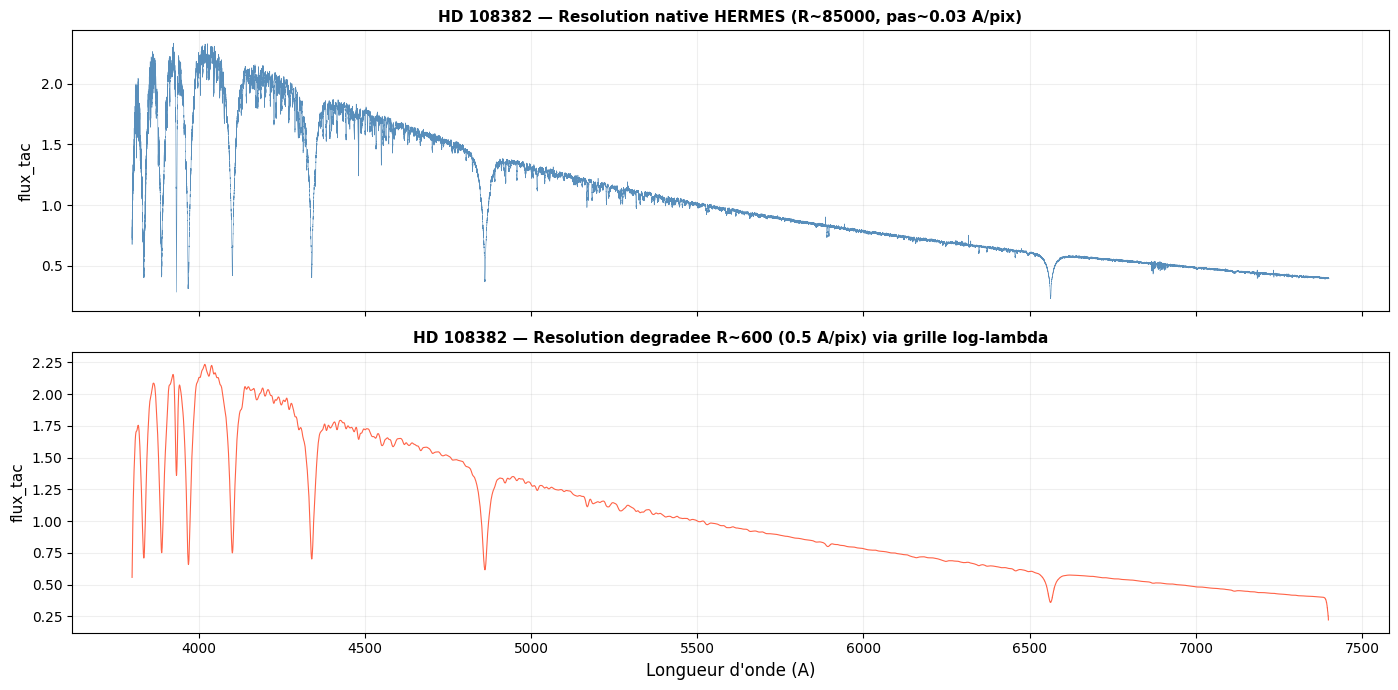

In [17]:
# Affichage comparatif : resolution native vs degradee
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# Spectre natif HERMES
sel = (w_ok >= LMIN_OUT) & (w_ok <= LMAX_OUT)
axes[0].plot(w_ok[sel], ft_ok[sel], color='steelblue', lw=0.4, alpha=0.9)
axes[0].set_ylabel('flux_tac', fontsize=11)
axes[0].set_title(f'HD {HD_NUMBER} — Resolution native HERMES (R~85000, pas~0.03 A/pix)',
                  fontsize=11, weight='bold')
axes[0].grid(True, alpha=0.2)

# Spectre degradé
axes[1].plot(w_deg, f_deg, color='tomato', lw=0.8)
axes[1].set_ylabel('flux_tac', fontsize=11)
axes[1].set_title(f'HD {HD_NUMBER} — Resolution degradee R~{R_TARGET} ({DELTA_OUT} A/pix) via grille log-lambda',
                  fontsize=11, weight='bold')
axes[1].set_xlabel('Longueur d\'onde (A)', fontsize=12)
axes[1].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()


In [18]:
# Export FITS 1D — resolution native et degradee

def export_fits(wave, flux, filename, resolpow, delta):
    hdr = fits.Header()
    hdr['SIMPLE']   = True
    hdr['BITPIX']   = -32
    hdr['NAXIS']    = 1
    hdr['NAXIS1']   = len(flux)
    hdr['CTYPE1']   = 'WAVE'
    hdr['CUNIT1']   = 'Angstrom'
    hdr['CRPIX1']   = 1.0
    hdr['CRVAL1']   = float(wave[0])
    hdr['CDELT1']   = float(delta)
    hdr['CD1_1']    = float(delta)
    hdr['OBJECT']   = str(meta['object'])[:68]
    hdr['DATE-OBS'] = str(meta['date_obs'])[:68]
    hdr['EXPTIME']  = float(meta['exptime'])
    hdr['INSTRUME'] = str(meta['instrume'])[:68]
    hdr['TELESCOP'] = str(meta['telescop'])[:68]
    hdr['BJD']      = float(meta['bjd'])
    hdr['BVCOR']    = float(meta['bvcor_kms'])
    hdr['RA']       = float(meta['ra'])
    hdr['DEC']      = float(meta['dec'])
    hdr['UNSEQ']    = int(meta['unseq'])
    hdr['ORIGIN']   = 'MELCHIORS/HERMES'
    hdr['FLUXTYPE'] = 'flux_tac'
    hdr['RESOLPOW'] = resolpow
    hdr['COMMENT']  = 'flux_tac: instrument + telluric corrected'
    fits.PrimaryHDU(data=flux.astype(np.float32), header=hdr).writeto(filename, overwrite=True)
    print(f"Export : {filename}  ({len(flux)} pixels, {wave[0]:.1f}-{wave[-1]:.1f} A, R~{resolpow})")
    print(f"  Taille : {os.path.getsize(filename)/1024:.1f} kB")

# Resolution native HERMES
delta_native = float(np.median(np.diff(w_ok)))
sel = (w_ok >= LMIN_OUT) & (w_ok <= LMAX_OUT)
fits_file_full = f'Melchiors_HD{HD_NUMBER}_full.fits'
export_fits(w_ok[sel], ft_ok[sel], fits_file_full, resolpow=85000, delta=delta_native)

# Resolution degradee
fits_file_deg = f'Melchiors_HD{HD_NUMBER}_R{R_TARGET}.fits'
export_fits(w_deg, f_deg, fits_file_deg, resolpow=R_TARGET, delta=DELTA_OUT)


Export : Melchiors_HD108382_full.fits  (128157 pixels, 3800.0-7400.0 A, R~85000)
  Taille : 503.4 kB
Export : Melchiors_HD108382_R600.fits  (7198 pixels, 3800.0-7398.5 A, R~600)
  Taille : 30.9 kB


In [19]:
# Telecharger les deux fichiers
from google.colab import files as colab_files
for f in [fits_file_full, fits_file_deg]:
    print(f'Telechargement : {f}')
    colab_files.download(f)

Telechargement : Melchiors_HD108382_full.fits


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Telechargement : Melchiors_HD108382_R600.fits


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>